In [1]:
%matplotlib inline
%reload_ext autoreload
%autoreload 2

import sys

sys.path.append('src')

In [2]:
import scanpy as sc

In [3]:
adata = sc.read_h5ad("../dsa/notebooks/synthetic_eval/synthetic_spatial_adata.h5ad")
adata.var.index = adata.var['gene_name-new']
domains_key = "region"
labels_key = 'cell_type'

In [4]:
# adata = sc.read(
#     f"../../data/crc_wt_cosmx/crc_242.h5ad",
#     backup_url=f"https://zenodo.org/records/15574384/files/242.h5ad?download=1"
# )
# # adata.obsm = {} # NOTE: only some strange PCA embeddings are stored in obsm, which we don't need
# adata.obs_names_make_unique()

# label_to_coarse = {
#     "epi1": "Epithelial",
#     "epi2": "Epithelial",
#     "epi3": "Epithelial",
#     "epi4": "Epithelial",
    
#     "fib1": "Fibroblast",
#     "fib2": "Fibroblast",
    
#     "EC": "Endothelial",
#     "SMC": "Smooth_muscle",
    
#     "BC": "B_cell",
#     "PC_IgA": "Plasma_cell",
#     "PC_IgG": "Plasma_cell",
#     "PC_IgM": "Plasma_cell",
    
#     "TC": "T_cell",
    
#     "mye1": "Myeloid",
#     "mye2": "Myeloid",
    
#     "mast": "Mast_cell",
# }

# adata.obs["coarse_type"] = adata.obs['ist'].map(label_to_coarse)
# labels_key = 'coarse_type'
# domains_key = 'typ'
# adata = adata[~adata.obs[domains_key].isna()] # NOTE: Interesting to annotate?
# adata = adata[~adata.obs[labels_key].isna()]
# adata.obs[labels_key] = adata.obs[labels_key].astype('category')
# adata.obsm['spatial'] = adata.obs[['CenterX_global_px', 'CenterY_global_px']].values
# adata.layers['counts'] = adata.X.copy()
# sc.pp.highly_variable_genes(adata, layer='counts', flavor='seurat_v3', n_top_genes=3000, subset=True)

In [5]:
adata.X

array([[4.0546355e-01, 1.3191858e-02, 5.7775020e-03, ..., 5.9586668e-01,
        3.1653152e+00, 1.6032119e-01],
       [3.0557573e-01, 8.0697797e-03, 1.0863479e-02, ..., 6.6156961e-02,
        3.4897977e-01, 1.3320860e-01],
       [4.1519508e+00, 1.3122945e+00, 1.4071622e-01, ..., 2.2332193e+01,
        6.9882057e+01, 7.2697718e-03],
       ...,
       [2.4183877e+00, 2.4768515e-01, 6.0280837e-02, ..., 6.2022386e+00,
        2.7243963e+01, 2.2268949e-02],
       [6.9999164e-01, 5.6562554e-02, 2.2703696e-02, ..., 1.7475737e+01,
        5.3366581e+01, 1.2229774e-02],
       [6.0382867e-01, 2.2771050e-01, 9.6838303e-02, ..., 6.5686679e-01,
        5.6160693e+00, 5.9514619e-02]], dtype=float32)

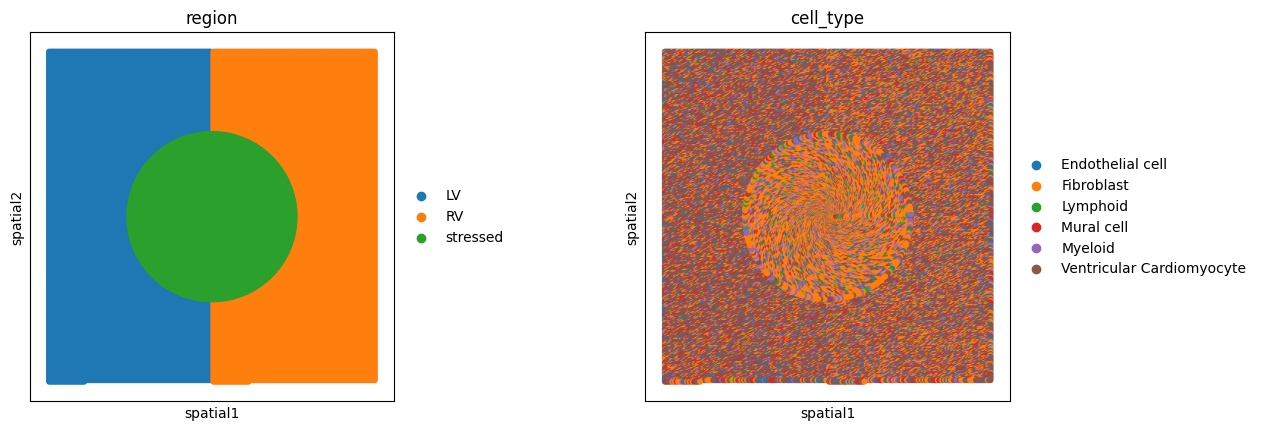

In [6]:
sc.pl.spatial(adata, color=[domains_key, labels_key], spot_size=20)

In [7]:
from anndata import AnnData
import numpy as np
from scipy.sparse import csr_matrix
from sklearn.neighbors import NearestNeighbors
from sklearn.preprocessing import normalize

from src.cellina._spatial_utils import weighted_pseudobulks, spatial_neighbors

In [8]:
n_neighbors = 20
spatial_neighbors(adata, bandwidth=np.inf, max_neighbours=n_neighbors, standardize=False)

In [9]:
adata.obs['neighbor'] = adata.obsp['spatial_connectivities'][:,0].toarray().astype(np.float32)

In [10]:
sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
adata.obsm['spatial_x'] = adata.obsp['spatial_connectivities'] @ adata.X

In [11]:
# NOTE: inefficient and issues with explosion of feature counts
# weighted_pseudobulks(
#     adata,
#     sp=adata.obsp['spatial_connectivities'],
#     groupby=labels_key
# )

In [12]:

# ndata = AnnData(adata.obsm['spatial_x'], obs=adata.obs, var=adata.uns['_spatial_var'], obsm=adata.obsm)
# ndata.var['average'] = ndata.X.mean(axis=0)
# ndata.var['std'] = ndata.X.std(axis=0)
# ndata.var['cv'] = ndata.var['std'] / ndata.var['average']

In [13]:
# ndata.var.set_index(0, inplace=True)

In [14]:
# ndata.var.sort_values('cv', ascending=False, key=abs).head(5)
# # TODO: need to move away from uniform representation of space

In [15]:
# sc.pl.spatial(ndata, color=['Ventricular Cardiomyocyte_CLDN5'], spot_size=5)

In [16]:
# top_genes_idx = np.abs(np.argsort(ndata.var['cv']))[-1000:]
# adata.obsm['spatial_x'] = adata.obsm['spatial_x'][:, top_genes_idx]

In [17]:
adata.obsm['spatial_x'].shape

(49800, 3000)

In [18]:
from cellina import CellinaModel

In [19]:
CellinaModel.setup_anndata(adata,
                           batch_key=None,
                           labels_key=labels_key, 
                           domains_key=domains_key, 
                           spatial_obsm_key="spatial_x",
                           layer='counts',
                           spatial_connectivities_key='spatial_connectivities')
model = CellinaModel(adata, n_latent=20, classifier_lambda=0, discriminator_lambda=0, condition_on_intrinsic=False, link_prediction_weight=10e5)

INFO     Generating sequential column names                                                                        


INFO     cellina: The Cellina model has been initialized with edge prediction                                      


In [20]:
model.train(max_epochs=50,
            check_val_every_n_epoch=1,
            early_stopping=True,
            early_stopping_patience=10,
            early_stopping_monitor='validation_loss', # NOTE: z/e kl + reconstruction
            train_size=0.9,
            validation_size=0.1,
            # default_root_dir='scvi_log/',
            plan_kwargs={'lr': 0.0001,
                         'weight_decay': 0.0001,
                         'normalize_losses': False,
                        #  "scale_adversarial_loss": "normalized"
                         },
            enable_checkpointing=True,
            # callbacks=[
            #     SaveCheckpoint(monitor="validation_loss",
            #                    load_best_on_end=True,
            #                    dirpath=f'scvi_log/synthetic/',
            #                    filename='test1'),
            # ],
            batch_size=2048,
            devices=[1]
            )

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
You are using a CUDA device ('NVIDIA GeForce RTX 4090') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0,1]
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/torch_geometric/loader/neighbor_loader.py:229: UserWarning: The usage of the 'directed' argument in 'NeighborSampler' is deprecated. Use `subgraph_type='induced'` instead.
  neighbor_sampler = NeighborSampler(


Training:   0%|          | 0/50 [00:00<?, ?it/s]

/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 29277. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 29301. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py:78: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 28973. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.
/data/ddimitrov/software/miniforge3/envs/cellina_edge/lib/python3.10/site-packages/lightning/pytorch/utilities/data.py

In [21]:
list(model.history_.keys())

['kl_weight',
 'train_loss_step',
 'validation_loss',
 'elbo_validation',
 'reconstruction_loss_validation',
 'kl_local_validation',
 'kl_global_validation',
 'vae_loss_validation',
 'classifier_loss_raw_validation',
 'classifier_loss_validation',
 'classifier_accuracy_validation',
 'fool_loss_raw_validation',
 'fool_loss_validation',
 'fool_accuracy_validation',
 'edge_prediction_loss_validation',
 'train_loss_epoch',
 'elbo_train',
 'reconstruction_loss_train',
 'kl_local_train',
 'kl_global_train',
 'vae_loss_train',
 'classifier_loss_raw_train',
 'classifier_loss_train',
 'classifier_accuracy_train',
 'fool_loss_raw_train',
 'fool_loss_train',
 'fool_accuracy_train',
 'edge_prediction_loss_train']

<Axes: xlabel='epoch'>

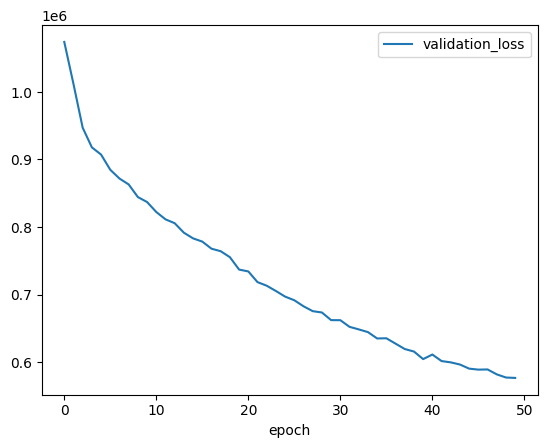

In [22]:
model.history_['validation_loss'].plot()

<Axes: xlabel='epoch'>

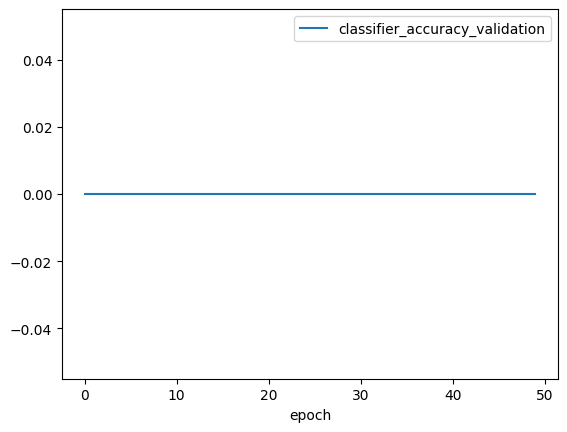

In [23]:
model.history_['classifier_accuracy_validation'].plot()

<Axes: xlabel='epoch'>

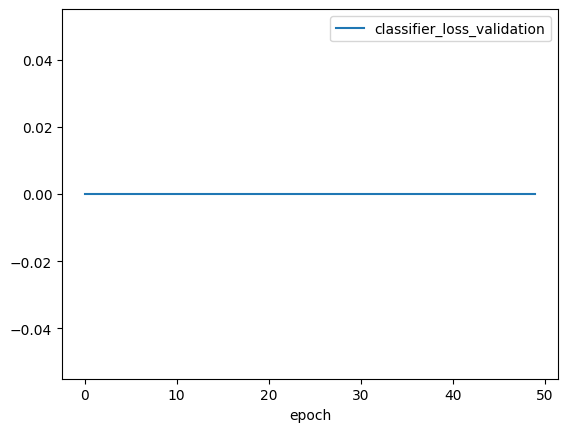

In [24]:
model.history_['classifier_loss_validation'].plot()

<Axes: xlabel='epoch'>

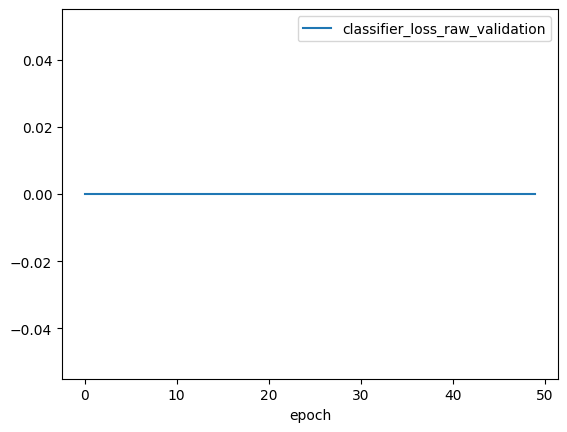

In [25]:
model.history_['classifier_loss_raw_validation'].plot()

In [26]:
if 'discriminator_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['discriminator_loss_validation'].plot()

In [27]:
model.history_.keys()

dict_keys(['kl_weight', 'train_loss_step', 'validation_loss', 'elbo_validation', 'reconstruction_loss_validation', 'kl_local_validation', 'kl_global_validation', 'vae_loss_validation', 'classifier_loss_raw_validation', 'classifier_loss_validation', 'classifier_accuracy_validation', 'fool_loss_raw_validation', 'fool_loss_validation', 'fool_accuracy_validation', 'edge_prediction_loss_validation', 'train_loss_epoch', 'elbo_train', 'reconstruction_loss_train', 'kl_local_train', 'kl_global_train', 'vae_loss_train', 'classifier_loss_raw_train', 'classifier_loss_train', 'classifier_accuracy_train', 'fool_loss_raw_train', 'fool_loss_train', 'fool_accuracy_train', 'edge_prediction_loss_train'])

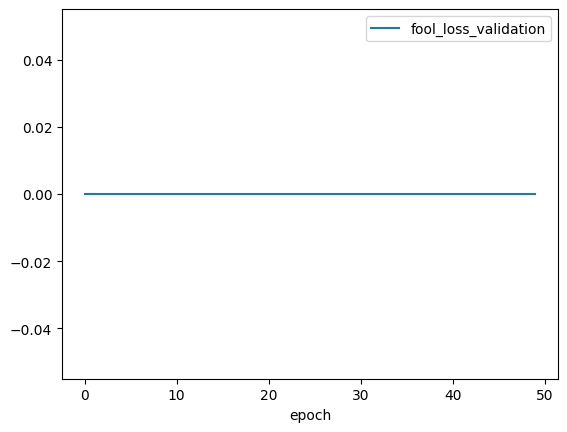

In [28]:
if 'fool_loss_validation' in model.history_: # NOTE: only if discriminator_lambda > 0
    model.history_['fool_loss_validation'].plot()

<Axes: xlabel='epoch'>

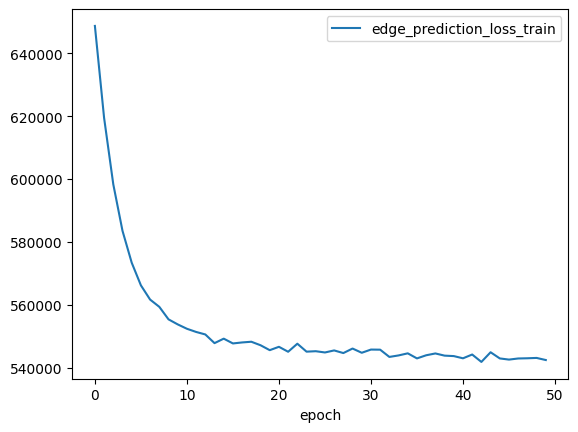

In [29]:
model.history_['edge_prediction_loss_train'].plot()

In [30]:
adata.obsm['z'] = model.get_latent_representation(latent_key='z')

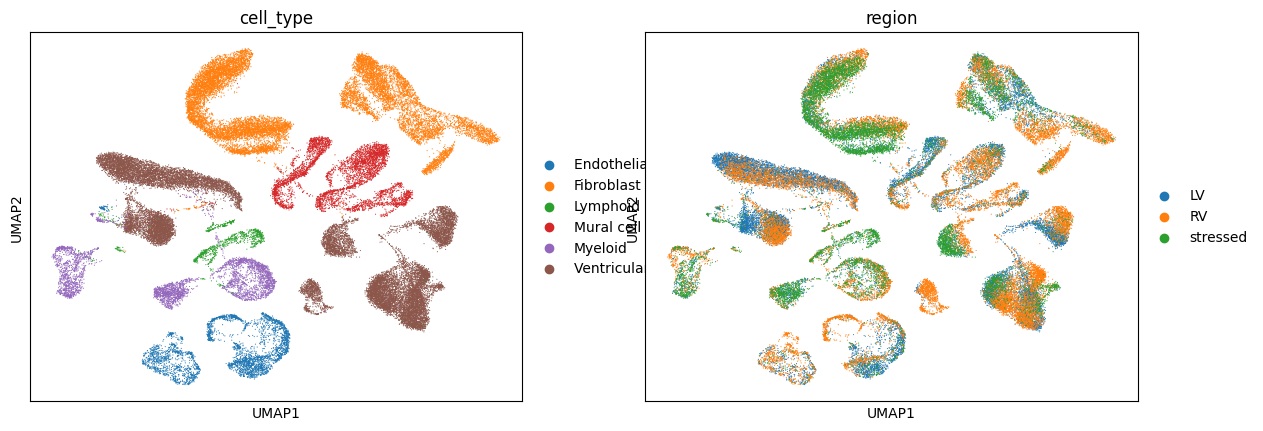

In [31]:
sc.pp.neighbors(adata, use_rep='z')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[labels_key, domains_key])

In [32]:
adata.obsm['z'].max()

np.float32(6.1669345)

In [33]:
adata.obsm['s'] = model.get_latent_representation(latent_key='s')

In [34]:
adata.obsm['s'].max()

np.float32(6.829992)

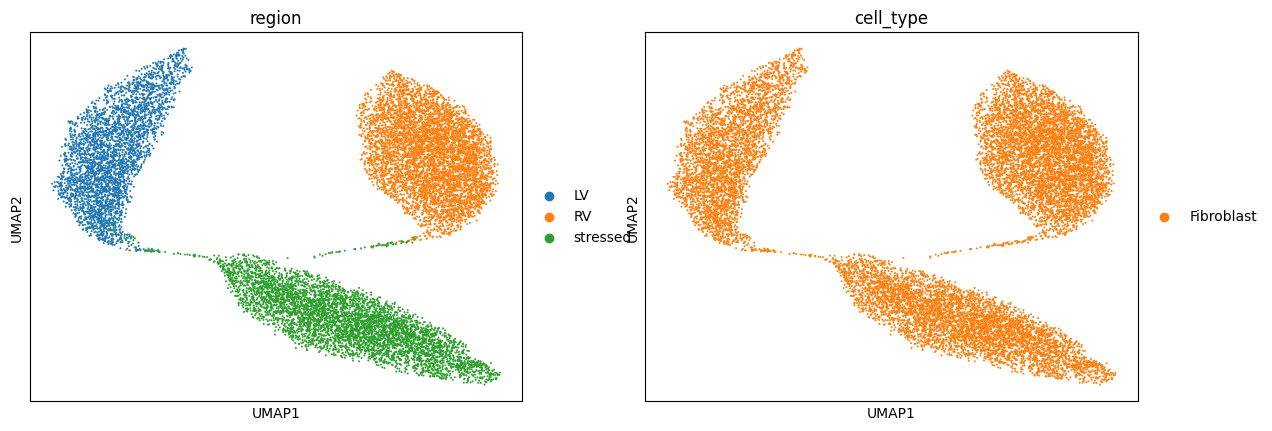

In [35]:
fib_adata = adata[adata.obs[labels_key]=='Fibroblast']
sc.pp.neighbors(fib_adata, use_rep='s')
sc.tl.umap(fib_adata)
sc.pl.umap(fib_adata, color=[domains_key, labels_key])

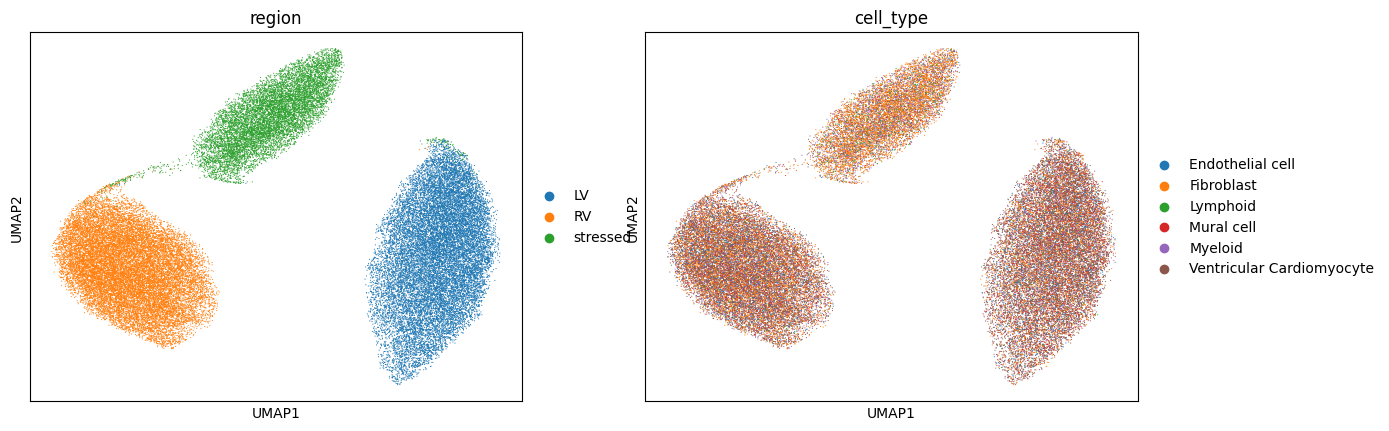

In [36]:
sc.pp.neighbors(adata, use_rep='s')
sc.tl.umap(adata)
sc.pl.umap(adata, color=[domains_key, labels_key])

In [37]:
def compute_spatial_metrics(adata, label_key: str, coord_key: str = 'spatial', exclude_labels=None) -> float:
    from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score, silhouette_samples
    import pandas as pd
    from scipy.spatial.distance import pdist, squareform

    adata.obs[label_key] = adata.obs[label_key].astype('category')
    
    if exclude_labels is not None:
        mask = ~adata.obs[label_key].isin(exclude_labels)
        ad = adata[mask].copy()
    else:
        ad = adata

    labels = ad.obs[label_key].cat.codes.values
    spatial_coords = ad.obsm[coord_key]

    mean_asw = silhouette_score(X=spatial_coords, labels=labels, metric='euclidean')
    db_score = davies_bouldin_score(X=spatial_coords, labels=labels)
    ch_score = calinski_harabasz_score(X=spatial_coords, labels=labels)
    
    samples_asw = silhouette_samples(X=spatial_coords, labels=labels, metric='euclidean')
    
    df = pd.DataFrame(index=ad.obs_names, data={f'spatial_asw_{label_key}': samples_asw})
    asw_by_label = df.groupby(ad.obs[label_key])[f'spatial_asw_{label_key}'].mean().round(3)
    asw_by_label.index.name = label_key
    asw_by_label = asw_by_label.to_dict()
    
    global_scores = {
        'asw ↑': round(mean_asw, 3),
        'db_score ↓': round(db_score, 3),
        'ch_score ↑': round(ch_score, 3)
    }
    
    return global_scores, asw_by_label

In [ ]:
# Nearest Neighbours and Leiden Clustering
sc.pp.neighbors(adata, use_rep='s')
sc.tl.umap(adata, neighbors_key='neighbors')
sc.tl.leiden(adata, key_added='leiden_s', resolution=0.1)


/tmp/ipykernel_3947983/3176027427.py:4: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata, key_added='leiden_s', resolution=0.1)


In [ ]:
compute_spatial_metrics(adata, label_key='leiden_s', coord_key='spatial')
# NOTE: OG region label
# ({'asw ↑': np.float64(0.142),
#   'db_score ↓': np.float64(1.574),
#   'ch_score ↑': np.float64(16227.848)},
#  {'LV': 0.046, 'RV': 0.045, 'stressed': 0.525})
# NOTE: No edge loss
# {'asw ↑': np.float64(-0.063),
#   'db_score ↓': np.float64(165.968),
#   'ch_score ↑': np.float64(0.556)},
#  {'0': -0.222, '1': 0.583})
# NOTE: With edge loss
# ({'asw ↑': np.float64(0.14),
#   'db_score ↓': np.float64(1.567),
#   'ch_score ↑': np.float64(16252.333)},
#  {'0': 0.044, '1': 0.043, '2': 0.533})

/tmp/ipykernel_3947983/3654632409.py:24: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  asw_by_label = df.groupby(ad.obs[label_key])[f'spatial_asw_{label_key}'].mean().round(3)


({'asw ↑': np.float64(0.14),
  'db_score ↓': np.float64(1.567),
  'ch_score ↑': np.float64(16252.333)},
 {'0': 0.044, '1': 0.043, '2': 0.533})

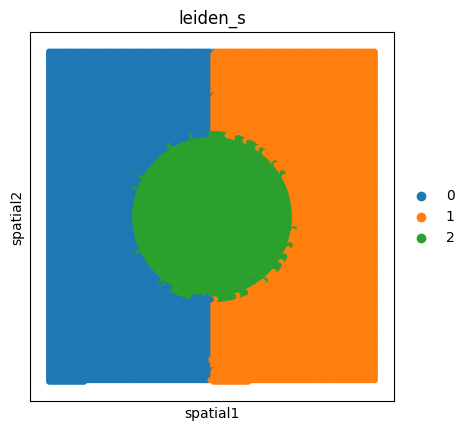

In [43]:
sc.pl.spatial(adata, color=['leiden_s'], spot_size=20)

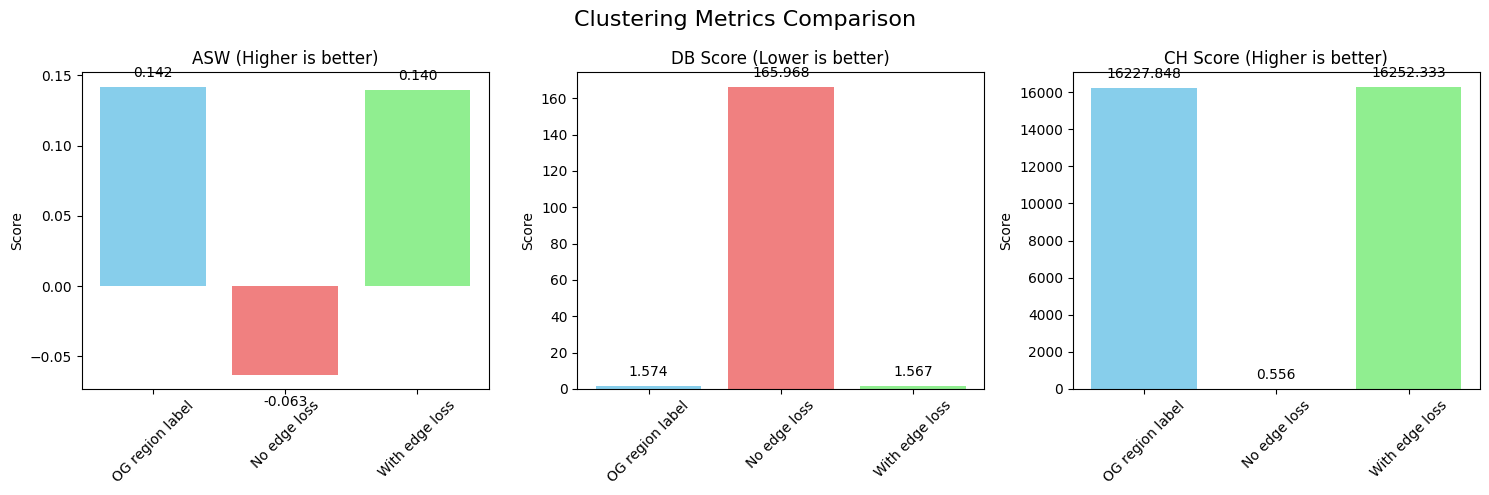

In [44]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

# Data setup
data = {
    "OG region label": {'asw': 0.142, 'db_score': 1.574, 'ch_score': 16227.848},
    "No edge loss": {'asw': -0.063, 'db_score': 165.968, 'ch_score': 0.556},
    "With edge loss": {'asw': 0.14, 'db_score': 1.567, 'ch_score': 16252.333}
}

df = pd.DataFrame(data).T

# Setup plot
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Clustering Metrics Comparison', fontsize=16)

# Metric definitions for iteration
metrics = [
    ('asw', 'ASW (Higher is better)'), 
    ('db_score', 'DB Score (Lower is better)'), 
    ('ch_score', 'CH Score (Higher is better)')
]

colors = ['skyblue', 'lightcoral', 'lightgreen']

for i, (col, title) in enumerate(metrics):
    ax = axes[i]
    bars = ax.bar(df.index, df[col], color=colors)
    
    ax.set_title(title)
    ax.set_ylabel('Score')
    ax.tick_params(axis='x', rotation=45)
    
    # Add value annotations
    for bar in bars:
        height = bar.get_height()
        
        # Adjust label position for negative bars
        y_offset = 5 if height >= 0 else -15
        va = 'bottom' if height >= 0 else 'top'
        
        ax.annotate(f'{height:.3f}',
                    xy=(bar.get_x() + bar.get_width() / 2, height),
                    xytext=(0, y_offset),
                    textcoords="offset points",
                    ha='center', va=va)

plt.tight_layout()
plt.show()